In [2]:
# 기본 준비

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier


wine = pd.read_csv("./data/red-wine-quality.csv")

data = wine[["alcohol", "sugar", "pH"]].to_numpy()
target = wine["class"].to_numpy()

feature_names = ["alcohol", "sugar", "pH"]

,max_depth,train_score,test_score
0,1.0,0.757937,0.737692
1,2.0,0.809890,0.796154
2,3.0,0.845488,0.841538
3,4.0,0.857225,0.848462
4,5.0,0.867231,0.860769
5,6.0,0.876660,0.853077
6,7.0,0.889552,0.863846
7,8.0,0.900327,0.858462
8,10.0,0.929190,0.846154
9,12.0,0.955551,0.853077


최적 max_depth: 7.0
훈련 데이터 점수: 0.8895516644217818
테스트 데이터 점수: 0.8638461538461538


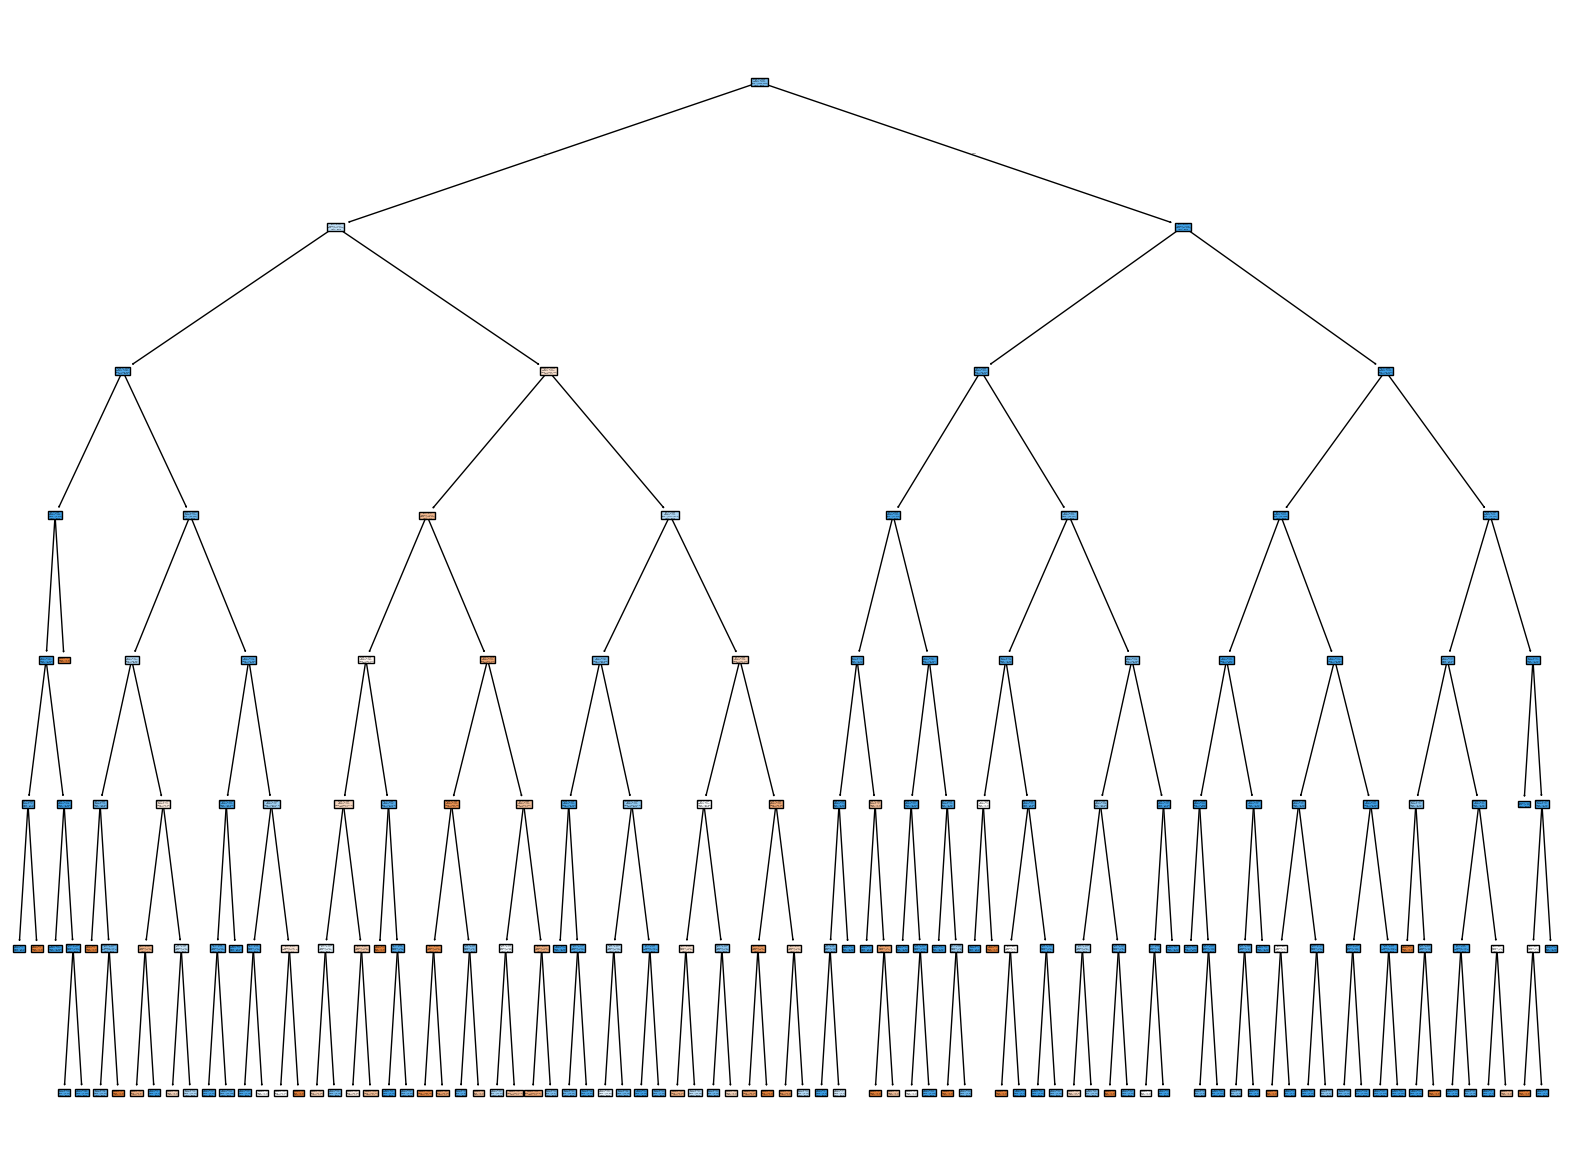

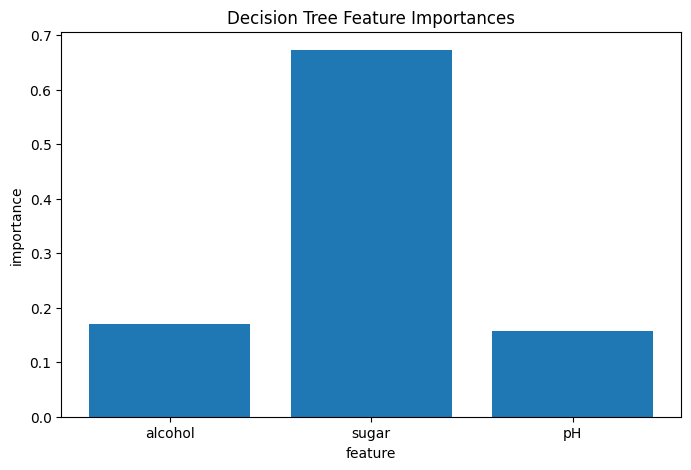

결론: 최적 max_depth는 7.0이며, 이때 테스트 정확도는 0.8638이다.


In [3]:
# 1. 와인 결정 트리 — max_depth 과적합 실험

train_input, test_input, train_target, test_target = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42
)


# DecisionTreeClassifier(max_depth=d, random_state=42) 루프 작성

depth_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 14, None]

result = []

for d in depth_list:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)

    # 스케일링 없이 바로 fit 사용 (이유 주석 기재)
    # 결정트리는 조건 분기로 데이터를 나누는 모델이므로 특성 스케일 차이에 거의 영향을 받지 않는다.

    dt.fit(train_input, train_target)

    train_score = dt.score(train_input, train_target)
    test_score = dt.score(test_input, test_target)

    result.append([d, train_score, test_score])


depth_df = pd.DataFrame(
    result,
    columns=["max_depth", "train_score", "test_score"]
)

display(depth_df)


best_row = depth_df.loc[depth_df["test_score"].idxmax()]
best_depth = best_row["max_depth"]

dt_best = DecisionTreeClassifier(
    max_depth=None if best_depth is None else int(best_depth),
    random_state=42
)

dt_best.fit(train_input, train_target)

print("최적 max_depth:", best_depth)
print("훈련 데이터 점수:", dt_best.score(train_input, train_target))
print("테스트 데이터 점수:", dt_best.score(test_input, test_target))


plt.figure(figsize=(20, 15))
plot_tree(
    dt_best,
    filled=True,
    feature_names=feature_names,
    class_names=["red", "white"]
)
plt.show()


# feature_importances_ 배열을 bar 차트로 시각화

dt_importances = dt_best.feature_importances_

plt.figure(figsize=(8, 5))
plt.bar(feature_names, dt_importances)
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Decision Tree Feature Importances")
plt.show()


# 최적 max_depth를 한 문장으로 결론 작성

print(
    f"결론: 최적 max_depth는 {best_depth}이며, "
    f"이때 테스트 정확도는 {best_row['test_score']:.4f}이다."
)

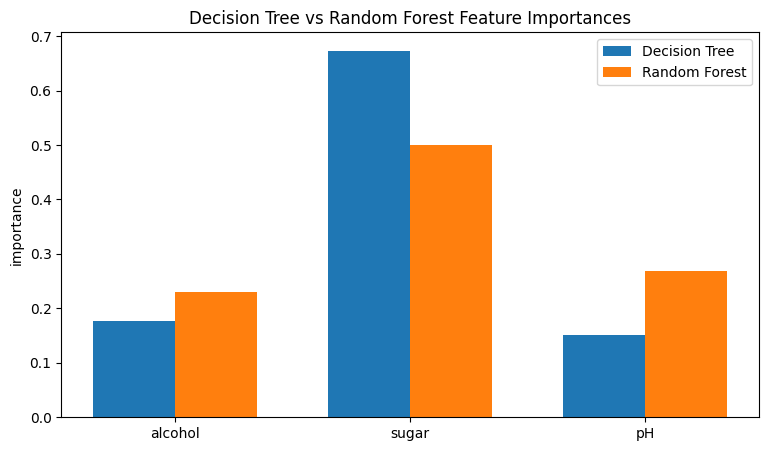

RF OOB score: 0.8964787377333077
RF CV score: 0.8937817428000298
RF hold-out score: 0.8892307692307693


In [4]:
# 2. sklearn 와인 — 결정 트리 vs Random Forest 특성 중요도 비교

# stratify=y 옵션으로 클래스 비율 유지

train_input, test_input, train_target, test_target = train_test_split(
    data,
    target,
    test_size=0.2,
    random_state=42,
    stratify=target
)


dt = DecisionTreeClassifier(
    max_depth=None if best_depth is None else int(best_depth),
    random_state=42
)

dt.fit(train_input, train_target)


rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)

rf.fit(train_input, train_target)


# DT feature_importances_ vs RF feature_importances_ 시각적 비교

dt_importances = dt.feature_importances_
rf_importances = rf.feature_importances_

x = np.arange(len(feature_names))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, dt_importances, width, label="Decision Tree")
plt.bar(x + width / 2, rf_importances, width, label="Random Forest")
plt.xticks(x, feature_names)
plt.ylabel("importance")
plt.title("Decision Tree vs Random Forest Feature Importances")
plt.legend()
plt.show()


# RF OOB 점수 출력 (oob_score=True)

print("RF OOB score:", rf.oob_score_)


rf_scores = cross_validate(
    rf,
    train_input,
    train_target,
    cv=5,
    return_train_score=True,
    n_jobs=-1
)

rf_cv_score = rf_scores["test_score"].mean()
rf_holdout_score = rf.score(test_input, test_target)

print("RF CV score:", rf_cv_score)
print("RF hold-out score:", rf_holdout_score)


# RF hold-out=1.000 경험 시 CV 점수와 비교 후 주석 기재
# CV 점수는 여러 fold의 평균이고, hold-out 점수는 따로 분리한 test 샘플 한 묶음의 점수이므로 sample 구성 차이 때문에 다르게 나올 수 있다.

In [5]:
# 3. sklearn 와인 — RF + GridSearchCV 최고 CV 점수 달성

# param_grid 정의 후 총 조합 수 계산

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 8, 10, 12, 14],
    "min_samples_split": [2, 4, 8],
    "min_impurity_decrease": [0.0, 0.0002, 0.0004]
}

total_combinations = (
    len(param_grid["n_estimators"])
    * len(param_grid["max_depth"])
    * len(param_grid["min_samples_split"])
    * len(param_grid["min_impurity_decrease"])
)

print("총 조합 수:", total_combinations)


rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)


# GridSearchCV(..., return_train_score=True) 설정

gs = GridSearchCV(
    rf_base,
    param_grid,
    cv=5,
    n_jobs=-1,
    return_train_score=True
)

gs.fit(train_input, train_target)

print("best_params_:", gs.best_params_)
print("best_score_:", gs.best_score_)


# gs.best_estimator_로 별도 fit() 없이 바로 test 점수 산출

best_rf = gs.best_estimator_

print("best_estimator_ test score:", best_rf.score(test_input, test_target))


# CV 점수와 hold-out 점수 차이를 sample 수 관점에서 설명

cv_score = gs.best_score_
holdout_score = best_rf.score(test_input, test_target)

print("CV score:", cv_score)
print("Hold-out test score:", holdout_score)
print("difference:", abs(cv_score - holdout_score))

print(
    "설명: CV 점수는 train_input을 여러 fold로 나누어 평균을 낸 점수이고, "
    "hold-out 점수는 따로 분리한 test_input 샘플로 한 번 평가한 점수이다. "
    "따라서 사용된 sample 수와 sample 구성이 달라 점수 차이가 발생할 수 있다."
)

총 조합 수: 90
best_params_: {'max_depth': None, 'min_impurity_decrease': 0.0, 'min_samples_split': 2, 'n_estimators': 100}
best_score_: 0.8937817428000298
best_estimator_ test score: 0.8892307692307693
CV score: 0.8937817428000298
Hold-out test score: 0.8892307692307693
difference: 0.004550973569260486
설명: CV 점수는 train_input을 여러 fold로 나누어 평균을 낸 점수이고, hold-out 점수는 따로 분리한 test_input 샘플로 한 번 평가한 점수이다. 따라서 사용된 sample 수와 sample 구성이 달라 점수 차이가 발생할 수 있다.
